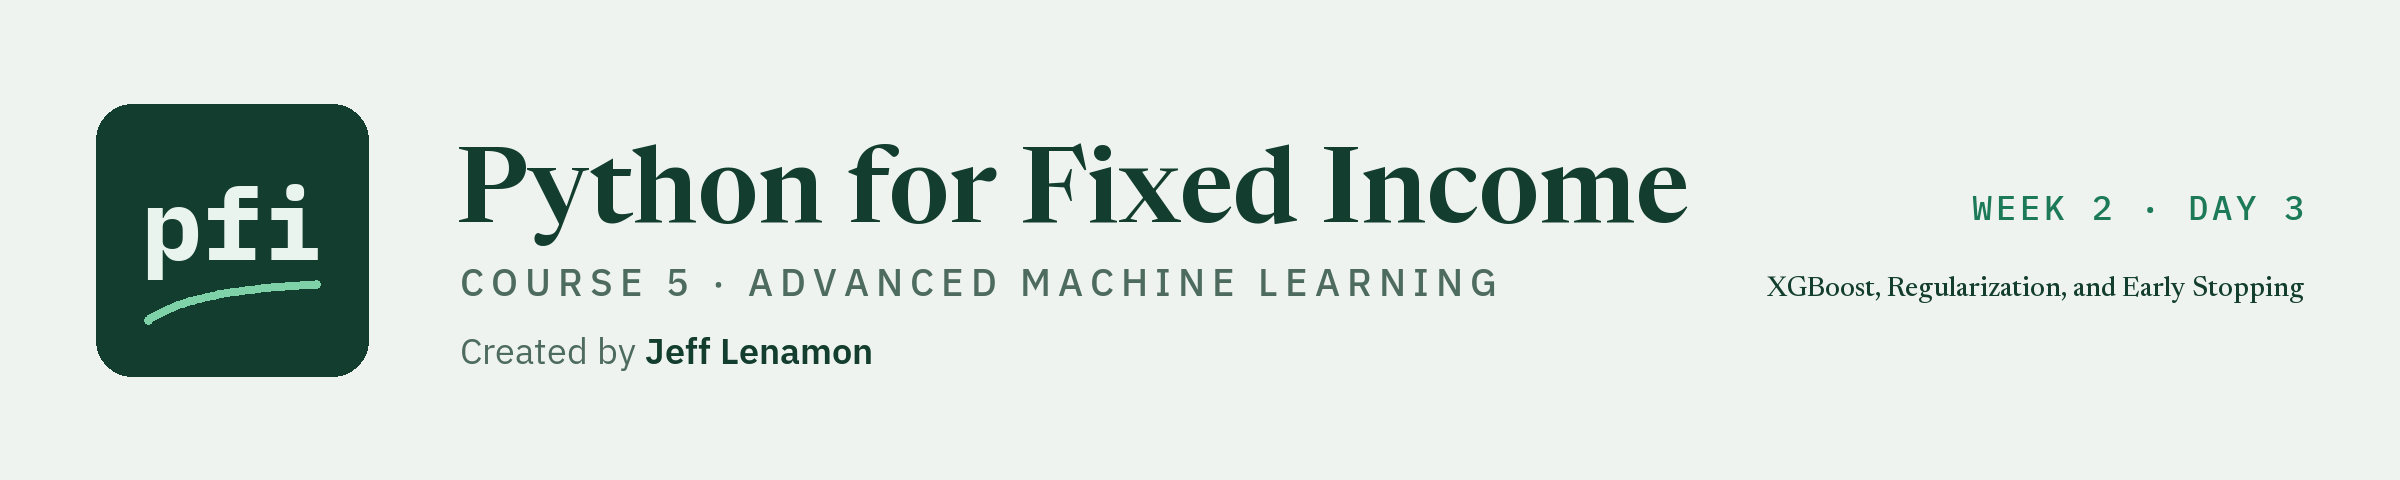

# XGBoost, Regularization, and Early Stopping

Week 2, Day 3. XGBoost is gradient boosting with brakes. Today: the penalty on each leaf, by hand; how the defaults overfit the card file; each brake one at a time; early stopping on rows carved from the training rows; and a weight for the rare class.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week2/day3/08_xgboost_regularization_and_early_stopping.ipynb)

Day 7 built gradient boosting from residuals: start from the mean, fit a small tree to what is left, add a fraction of it, repeat. XGBoost does the same on the card file's 0 or 1 outcome, working on log-odds, and adds brakes: a penalty that shrinks every leaf value, a minimum gain a split must clear, and random samples of rows and columns for each tree. Today you take the library apart one setting at a time and see what each one does on Course 4's card rows. Then you let rows carved from the training rows decide when to stop adding trees, so the validation rows choose nothing.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` holds 30,000 credit card accounts in Taiwan in 2005, with payment records from April to September and an outcome for the following month. Consumer credit there differs from US credit, and nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are not in any model, and no output is grouped by them. Every model today uses Course 4's other 19 columns.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed, under the test-row rule day 1 stated for the whole course.
* **A model's output is described, never acted on.** XGBoost's output is the model probability of default in this file, or a flag at a threshold; a model fitted with a class weight gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. Read one XGBoost stump and compute its two leaf values by hand, with and without the penalty.
2. Fit `XGBClassifier` with `n_jobs=1` written out, and read the settings it used.
3. Watch the defaults overfit as trees are added.
4. Turn on each brake one at a time.
5. Stop adding trees on rows carved from the training rows, with `early_stopping_rows`.
6. Weight the rare class with `scale_pos_weight`, and see what it does to the output's average.
7. Put XGBoost beside Course 4's models and day 3's forest.
8. Compute log loss, the number each tree makes smaller, by hand.

Q. Set up today's work folder: the thread settings, the seed, and the card file.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_08_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_08_2984gnjx, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp']


* `ensemblekit.py` holds days 1 to 7, and its tests are the 28 the module had at the end of day 7. The benchmark and ratings files are copied because day 5's tests read them.
* XGBoost uses every core unless told otherwise, so every `XGBClassifier` below is written with `n_jobs=1`. Section 8.2 says why that matters more for XGBoost than for anything so far.

Q. Load the card accounts and take Course 4's training and validation rows.

In [6]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

print(f"training rows: {len(X_train):,}, default rate {y_train.mean():.4f}")
print(f"validation rows: {len(X_valid):,}, default rate {y_valid.mean():.4f}")

training rows: 18,000, default rate 0.2212
validation rows: 6,000, default rate 0.2212


* 18,000 and 6,000 rows, the same default rate to three decimals (0.2212 and 0.2212).

## 8.1 What XGBoost Adds: a Penalty on Every Leaf

On day 7 each round fitted a tree to residuals, `y - F`. For a 0 or 1 outcome XGBoost works on log-odds and uses two numbers per row instead of a residual: the **gradient** `g = p - y` and the **hessian** `h = p(1 - p)`, where `p` is the model probability of default so far. Both come from log loss, the number the trees make smaller (section 8.8). A leaf's value is then

**leaf value = -learning_rate x G / (H + lambda)**

where `G` and `H` are the sums of `g` and `h` over the training rows in the leaf, and `lambda` is the penalty `reg_lambda`. With `lambda = 0` a leaf moves the log-odds by a full Newton step; a larger `lambda` shrinks every leaf toward zero, and shrinks small leaves (small `H`) the most.

Q. Fit one XGBoost tree with one split, a stump, and read it.

In [7]:
import json

from xgboost import XGBClassifier

# one tree of depth 1: a single split and two leaves. n_jobs=1 on every XGBoost model (section 8.2)
stump = XGBClassifier(n_estimators=1, max_depth=1, random_state=SEED, n_jobs=1).fit(X_train, y_train)

# the starting probability XGBoost stored, read from the model's saved settings
config = json.loads(stump.get_booster().save_config())
base_score = config["learner"]["learner_model_param"]["base_score"]
print(f"starting probability (base_score): {base_score}; training default rate {y_train.mean():.8f}")

# the tree as a table: the split row, then the two leaves (for a leaf, the Gain column holds the leaf value)
tree = stump.get_booster().trees_to_dataframe()
print(tree[["ID", "Feature", "Split", "Yes", "No", "Gain", "Cover"]].to_string())

starting probability (base_score): [2.2122222E-1]; training default rate 0.22122222
    ID Feature  Split   Yes    No       Gain      Cover
0  0-0   PAY_0    2.0   0-1   0-2  2809.1199  3101.0933
1  0-1    Leaf   <NA>  <NA>  <NA>  -0.097755  2776.3398
2  0-2    Leaf   <NA>  <NA>  <NA>   0.833449   324.7534


* XGBoost starts every account at 0.22122222, the training default rate (stored in float32, so to eight digits), as day 7's boosting started from the mean.
* The stump asks `PAY_0 < 2`: XGBoost writes a split as "less than", where scikit-learn writes "less than or equal to". The left leaf's value is -0.0978 and the right leaf's 0.8334, in log-odds. `Cover` is the sum of the hessians, `H`.

Q. Compute the two leaf values by hand with XGBoost's defaults: learning rate 0.3 and `reg_lambda` 1.

In [8]:
# every row starts at the training default rate
p0 = y_train.mean()
g = p0 - y_train            # gradient of log loss for each training row
h = p0 * (1 - p0)           # hessian: the same for every row at the start

feature, split = tree.loc[0, "Feature"], tree.loc[0, "Split"]
left = X_train[feature] < split

# leaf value = -learning_rate * G / (H + lambda), with learning rate 0.3 and lambda 1
learning_rate, lam = 0.3, 1
leaf_left = -learning_rate * g[left].sum() / (h * left.sum() + lam)
leaf_right = -learning_rate * g[~left].sum() / (h * (~left).sum() + lam)

print(f"left leaf:  by hand {leaf_left:.6f}, XGBoost {tree.loc[1, 'Gain']:.6f}")
print(f"right leaf: by hand {leaf_right:.6f}, XGBoost {tree.loc[2, 'Gain']:.6f}")
print(f"within 1e-6: {abs(leaf_left - tree.loc[1, 'Gain']) < 1e-6 and abs(leaf_right - tree.loc[2, 'Gain']) < 1e-6}")

left leaf:  by hand -0.097755, XGBoost -0.097755
right leaf: by hand 0.833449, XGBoost 0.833449
within 1e-6: True


* The hand values equal XGBoost's to six decimals. They are not equal to twelve because XGBoost computes in float32, about seven significant digits; the course never prints an XGBoost number beyond four decimals.
* 1,885 accounts answer no (`PAY_0` of 2 or more, a delay of two months or more) and their log-odds rise by 0.8334; the other 16,115 fall by 0.0978.

Q. What does `reg_lambda` do to the leaves? Fit the stump with lambda 0, 1, and 100.

In [9]:
rows = []
for lam_k in [0, 1, 100]:
    model = XGBClassifier(n_estimators=1, max_depth=1, reg_lambda=lam_k, random_state=SEED, n_jobs=1).fit(X_train, y_train)
    t = model.get_booster().trees_to_dataframe()
    left_k = X_train[t.loc[0, "Feature"]] < t.loc[0, "Split"]
    rows.append({"reg_lambda": lam_k, "split": f"{t.loc[0, 'Feature']} < {t.loc[0, 'Split']:g}",
                 "gain": round(t.loc[0, "Gain"], 1),
                 "left leaf": round(t.loc[1, "Gain"], 4), "right leaf": round(t.loc[2, "Gain"], 4),
                 "right by hand": round(-0.3 * g[~left_k].sum() / (h * (~left_k).sum() + lam_k), 4)})
print(pd.DataFrame(rows).to_string(index=False))

 reg_lambda     split   gain  left leaf  right leaf  right by hand
          0 PAY_0 < 2 2817.0    -0.0978      0.8360         0.8360
          1 PAY_0 < 2 2809.1    -0.0978      0.8334         0.8334
        100 PAY_0 < 1 2279.0    -0.1428      0.4351         0.4351


* Lambda 1 against 0 barely moves the leaves: with 1,885 rows on the small side, `H` is in the hundreds and adding 1 changes little. At lambda 100 the right leaf shrinks from 0.8360 to 0.4351.
* At lambda 100 the split itself moves, to `PAY_0 < 1`: the penalty also enters the gain each candidate split is ranked by, and it costs a split with a small side more. The hand formula still gives XGBoost's leaf for the split it chose.

The second brake is `gamma` (also called `min_split_loss`): a split is kept only if its gain is above `gamma`. The stump's split above has a gain of 2809.1 as the tree table reports it.

Q. Fit the stump with `gamma` just below and just above that gain.

In [10]:
for gamma in [2809, 2810]:
    model = XGBClassifier(n_estimators=1, max_depth=1, gamma=gamma, random_state=SEED, n_jobs=1).fit(X_train, y_train)
    nodes = len(model.get_booster().trees_to_dataframe())
    print(f"gamma {gamma}: {nodes} node(s)" + (", the split is kept" if nodes == 3 else ", no split: one leaf"))

gamma 2809: 3 node(s), the split is kept
gamma 2810: 1 node(s), no split: one leaf


* At gamma 2809 the split stays; at 2810 it is gone and the tree is one leaf. So `gamma` is compared with the gain exactly as the tree table prints it. Deeper in a tree, splits fit fewer rows and have far smaller gains, so a modest `gamma` removes them and leaves the strong early splits alone.
* Two more brakes are named here and tried in section 8.4: `reg_alpha`, a penalty that pulls a leaf's `G` toward zero before dividing, and `subsample` and `colsample_bytree`, which give each tree a random share of the rows and of the columns.

## 8.2 XGBClassifier, with n_jobs=1 Written Out

`XGBClassifier` follows the scikit-learn pattern you know: `fit`, `predict_proba`, `get_params`. Two settings are written out on every one in this course. `random_state=SEED` fixes the random choices, as everywhere. `n_jobs=1` is the new one. XGBoost's default uses every core of the machine, and with row or column sampling its results can depend on how many threads it used, so the same code can give different probabilities on a machine with a different number of cores. With `n_jobs=1` the build of this notebook gives the same digits on one thread and on every core, which it checks on every run.

Q. Fit XGBoost with its defaults and 300 trees, and read the settings it used.

In [11]:
# XGBoost's defaults, with 300 trees
model_default = XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=1).fit(X_train, y_train)

# the settings the trees were grown with, read from the fitted model
used = json.loads(model_default.get_booster().save_config())["learner"]["gradient_booster"]["tree_train_param"]
for name in ["eta", "max_depth", "lambda", "alpha", "gamma", "min_child_weight", "subsample", "colsample_bytree"]:
    print(f"{name}: {float(used[name]):g}")

eta: 0.3
max_depth: 6
lambda: 1
alpha: 0
gamma: 0
min_child_weight: 1
subsample: 1
colsample_bytree: 1


* The defaults: learning rate (`eta`) 0.3, trees 6 levels deep, `lambda` 1, no `alpha`, no `gamma`, every row and every column for every tree. `min_child_weight` 1 is a floor on a leaf's `H`. The constructor shows most of these as `None`, which means "use the library's default"; the saved config shows the values actually used.

> **STORY: where the name comes from.** In August 2016 Tianqi Chen and Carlos Guestrin published a paper titled "XGBoost: A Scalable Tree Boosting System" in the *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pages 785 to 794). Its title holds the name of the library this notebook uses, and "tree boosting" is what day 7 built by hand.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1145/2939672.2939785, DOI https://doi.org/10.1145/2939672.2939785. Only the title, authors, proceedings, pages, and date are taken from it; the paper itself was not read for this course.

## 8.3 The Defaults Overfit

A boosted model is a sum of trees, so one fitted model holds every shorter model inside it: `predict_proba(X, iteration_range=(0, k))` uses only the first `k` trees.

Q. Score the default model on the training and validation rows after 1, 5, 10, ..., 300 trees.

In [12]:
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

counts = [1] + list(range(5, 301, 5))
curve = []
for k in counts:
    proba_train = model_default.predict_proba(X_train, iteration_range=(0, k))[:, 1]
    proba_valid = model_default.predict_proba(X_valid, iteration_range=(0, k))[:, 1]
    curve.append({"trees": k, "training ROC AUC": roc_auc_score(y_train, proba_train),
                  "validation ROC AUC": roc_auc_score(y_valid, proba_valid),
                  "validation log loss": log_loss(y_valid, proba_valid)})
curve = pd.DataFrame(curve).set_index("trees")
print(curve.loc[[1, 5, 10, 20, 50, 100, 200, 300]].round(4).to_string())

       training ROC AUC  validation ROC AUC  validation log loss
trees                                                           
1                0.7779              0.7516               0.4772
5                0.8118              0.7691               0.4388
10               0.8301              0.7726               0.4355
20               0.8589              0.7712               0.4384
50               0.9102              0.7660               0.4478
100              0.9550              0.7592               0.4635
200              0.9901              0.7519               0.4962
300              0.9973              0.7492               0.5249


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* The outputs are the model probability of default in this file. Training ROC AUC climbs with every tree, to 0.9973 at 300: the trees learn the training rows by heart. Validation ROC AUC is highest near 10 trees (0.7726) and falls to 0.7492 at 300, and validation log loss is lowest near 10 trees and rises after. With learning rate 0.3 and depth 6, the trees after the first few fit the training rows' noise faster than anything that holds on new rows.
* The validation rows describe the shape here; they choose nothing. The number of trees is chosen in section 8.5, on rows carved from the training rows.

Q. Draw both curves.

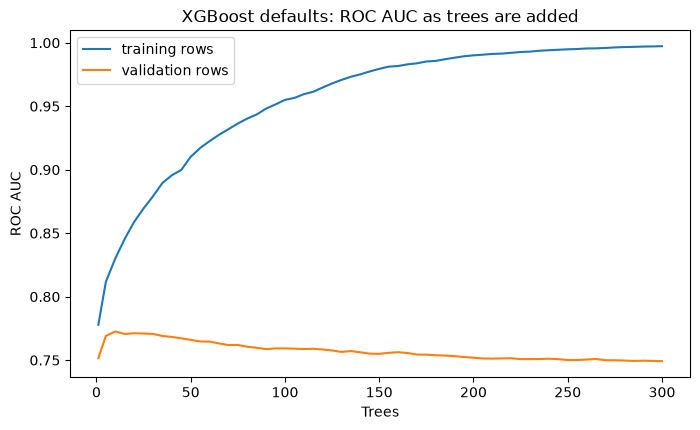

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve.index, curve["training ROC AUC"], label="training rows")
ax.plot(curve.index, curve["validation ROC AUC"], label="validation rows")
ax.set_title("XGBoost defaults: ROC AUC as trees are added")
ax.set_xlabel("Trees")
ax.set_ylabel("ROC AUC")
ax.legend()
plt.show()

* The gap between the two lines is the overfitting. Every brake in the next section is a way to narrow it.

## 8.4 Each Brake, One at a Time

Q. Keep the defaults and 300 trees, change one setting at a time, and score each model on the training and validation rows. Sampling is tried with `subsample` and `colsample_bytree` set to the same value.

In [14]:
settings = {"reg_lambda": [0, 1, 10, 100], "reg_alpha": [0, 1, 10, 100],
            "gamma": [0, 1, 5, 20], "subsample": [1.0, 0.8, 0.5]}
rows = []
for name, values in settings.items():
    for value in values:
        # sampling: the same share of rows and of columns for each tree
        change = {"subsample": value, "colsample_bytree": value} if name == "subsample" else {name: value}
        model = XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=1, **change).fit(X_train, y_train)
        auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
        auc_valid = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
        rows.append({"setting": name, "value": value, "training ROC AUC": auc_train, "validation ROC AUC": auc_valid,
                     "gap": auc_train - auc_valid})
brakes = pd.DataFrame(rows)
print(brakes.round(4).to_string(index=False))

   setting  value  training ROC AUC  validation ROC AUC    gap
reg_lambda    0.0            0.9985              0.7444 0.2540
reg_lambda    1.0            0.9973              0.7492 0.2481
reg_lambda   10.0            0.9878              0.7591 0.2287
reg_lambda  100.0            0.9417              0.7723 0.1695
 reg_alpha    0.0            0.9973              0.7492 0.2481
 reg_alpha    1.0            0.9978              0.7530 0.2448
 reg_alpha   10.0            0.8932              0.7780 0.1152
 reg_alpha  100.0            0.7895              0.7773 0.0122
     gamma    0.0            0.9973              0.7492 0.2481
     gamma    1.0            0.8607              0.7691 0.0915
     gamma    5.0            0.8171              0.7763 0.0407
     gamma   20.0            0.7864              0.7738 0.0126
 subsample    1.0            0.9973              0.7492 0.2481
 subsample    0.8            0.9974              0.7436 0.2538
 subsample    0.5            0.9903              0.7313

* **`reg_lambda`** narrows the gap steadily: at 100, training ROC AUC is 0.9417 and validation 0.7723, against 0.9973 and 0.7492 at the default.
* **`reg_alpha`** and **`gamma`** act harder on this file: `reg_alpha` 10 gives validation 0.7780 and `gamma` 5 gives 0.7763, with training ROC AUC down to 0.8932 and 0.8171. Both remove the small late splits that fit noise.
* **Sampling alone does not help here**: with 0.8 of the rows and columns, validation is 0.7436, and with 0.5, 0.7313, both below the default's 0.7492, while training stays near 0.9974. At learning rate 0.3 and depth 6 each tree still overfits its own sample. Sampling earns its place beside a small learning rate, as in the next section.
* Nothing is chosen from this table: it is on the validation rows, which report. The next section fixes its settings in advance (a learning rate of 0.05, depth 4, sampling 0.8) and lets rows carved from the training rows choose the one number left, how many trees.

Q. Draw the four settings side by side.

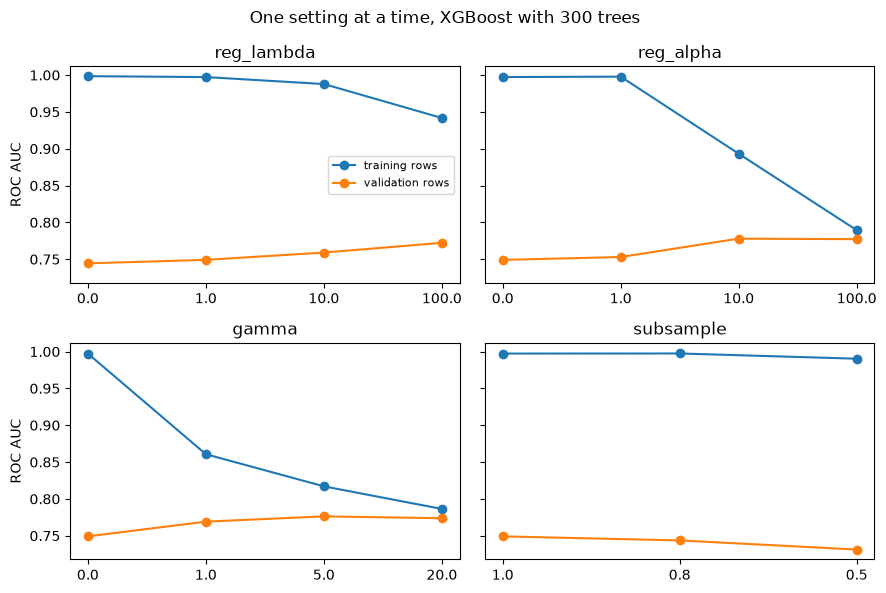

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=True)
for ax, (name, part) in zip(axes.flat, brakes.groupby("setting", sort=False)):
    labels = [str(v) for v in part["value"]]
    ax.plot(labels, part["training ROC AUC"], marker="o", label="training rows")
    ax.plot(labels, part["validation ROC AUC"], marker="o", label="validation rows")
    ax.set_title(name)
axes[0, 0].set_ylabel("ROC AUC")
axes[1, 0].set_ylabel("ROC AUC")
axes[0, 0].legend(fontsize=8)
fig.suptitle("One setting at a time, XGBoost with 300 trees")
fig.tight_layout()
plt.show()

* Three panels bring the lines together from above: the training line falls toward the validation line. The sampling panel does not.

## 8.5 Early Stopping on Rows Carved from the Training Rows

Early stopping adds trees one at a time and watches a score on rows the trees are not fitted on. When the score has not improved for a set number of rounds, it stops and keeps the best number of trees. The rows it watches choose the number of trees, so they cannot be the validation rows that report: the validation rows would then have chosen the model they score. Course 5's rule: **stop on rows carved from the training rows.**

Q. Add `early_stopping_rows` to `ensemblekit.py`. Read the docstring first.

In [16]:
%%writefile -a ensemblekit.py


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop

Appending to ensemblekit.py


* A stratified split of the training rows only, by `train_test_split` with the seed, checked with `mlkit.assert_disjoint`. The function refuses a share of 0, or of a half or more: the stopping rows are a small slice, and most rows still fit.

Q. Add its two tests.

In [17]:
%%writefile -a test_ensemblekit.py


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)

Appending to test_ensemblekit.py


* The first test is the rule in code: the stopping rows are inside the training rows, share no row with the validation rows, and have the training default rate within 0.001.

Q. Reload the module and run the tests.

In [18]:
importlib.reload(ensemblekit)
print(f"early_stopping_rows in ensemblekit: {hasattr(ensemblekit, 'early_stopping_rows')}")

early_stopping_rows in ensemblekit: True


In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............................                                           [100%]
30 passed in 9.87s



* `30 passed`: day 7's 28 and the two new ones.

Q. Carve the stopping rows out of the training rows.

In [20]:
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
# the stopping rows never touch the validation rows
mlkit.assert_disjoint(X_stop.index, X_valid.index)

print(f"fit rows: {len(X_fit):,}, default rate {y_fit.mean():.4f}")
print(f"stopping rows: {len(X_stop):,}, default rate {y_stop.mean():.4f}")

fit rows: 14,400, default rate 0.2213
stopping rows: 3,600, default rate 0.2211


* 14,400 rows fit and 3,600 rows decide when to stop, both from the 18,000 training rows.

Q. Fit XGBoost with a learning rate of 0.05, depth 4, and 0.8 of the rows and columns per tree, allowing up to 1,000 trees, and stop when the stopping rows' log loss has not improved for 50 rounds.

In [21]:
# early_stopping_rounds and eval_metric go in the constructor; fit gets the stopping rows as eval_set
model_es = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                         early_stopping_rounds=50, eval_metric="logloss", random_state=SEED, n_jobs=1)
model_es.fit(X_fit, y_fit, eval_set=[(X_stop, y_stop)], verbose=False)

stop_curve = model_es.evals_result()["validation_0"]["logloss"]
print(f"rounds run: {len(stop_curve)}; best_iteration: {model_es.best_iteration}, so {model_es.best_iteration + 1} trees are used")
print(f"stopping rows' log loss at the best round: {stop_curve[model_es.best_iteration]:.4f}")

# predict_proba uses the best number of trees by itself
proba_es = model_es.predict_proba(X_valid)[:, 1]
print(f"validation ROC AUC {roc_auc_score(y_valid, proba_es):.4f}, average precision {average_precision_score(y_valid, proba_es):.4f}")

rounds run: 159; best_iteration: 108, so 109 trees are used
stopping rows' log loss at the best round: 0.4350
validation ROC AUC 0.7788, average precision 0.5494


* XGBoost ran 159 rounds, found the lowest stopping-row log loss (0.4350) at round index 108, waited 50 more rounds without improvement, and stopped. `best_iteration` counts from 0, so the model uses 109 trees, and `predict_proba` uses them by itself.
* Validation ROC AUC 0.7788, against 0.7492 for the defaults: smaller steps, shallower trees, sampling, and a number of trees chosen on the training rows' own slice. The output is the model probability of default in this file.

Q. Draw the stopping rows' log loss, round by round.

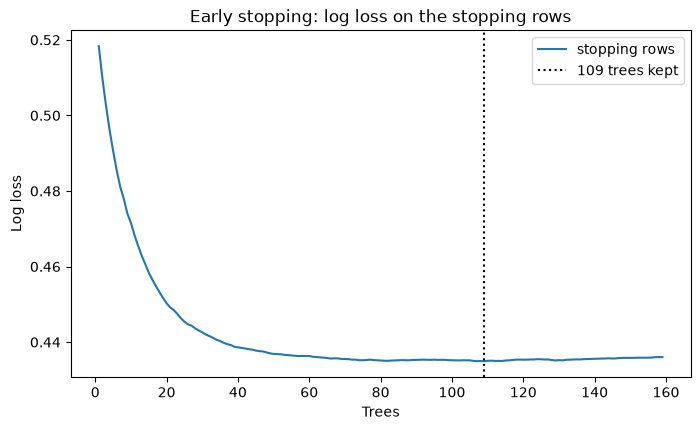

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(stop_curve) + 1), stop_curve, label="stopping rows")
ax.axvline(model_es.best_iteration + 1, color="black", linestyle=":", label=f"{model_es.best_iteration + 1} trees kept")
ax.set_title("Early stopping: log loss on the stopping rows")
ax.set_xlabel("Trees")
ax.set_ylabel("Log loss")
ax.legend()
plt.show()

* The curve falls fast, flattens, and turns up slowly. The dotted line is where the stopping rows put it; the fifty rounds after it are the patience that confirmed it.

## 8.6 The Rare Class: scale_pos_weight

About 22 percent of the training accounts default. XGBoost's `scale_pos_weight` multiplies the gradient and hessian of every class-1 row, so the defaults count more in each leaf. The usual value is the number of 0s divided by the number of 1s.

Q. Add `scale_pos_weight` to `ensemblekit.py`, and its two tests.

In [23]:
%%writefile -a ensemblekit.py


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)

Appending to ensemblekit.py


In [24]:
%%writefile -a test_ensemblekit.py


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])

Appending to test_ensemblekit.py


* The hand tests are small enough to check on paper: three 0s and one 1 give 3; four 0s and two 1s give 2. A `y` with no 1 is refused rather than divided by zero.

Q. Reload the module and run all of today's tests.

In [25]:
importlib.reload(ensemblekit)
print(f"scale_pos_weight in ensemblekit: {hasattr(ensemblekit, 'scale_pos_weight')}")

scale_pos_weight in ensemblekit: True


In [26]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................................                                         [100%]
32 passed in 9.40s



* `32 passed`.

Q. Fit the same settings with 300 trees on all 18,000 training rows, once without the weight and once with it. Compare the outputs' average and the ranking.

In [27]:
weight = ensemblekit.scale_pos_weight(y_train)
print(f"scale_pos_weight on the training rows: {weight:.4f}")

model_300 = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                          random_state=SEED, n_jobs=1).fit(X_train, y_train)
model_weighted = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                               scale_pos_weight=weight, random_state=SEED, n_jobs=1).fit(X_train, y_train)
proba_300 = model_300.predict_proba(X_valid)[:, 1]
score_weighted = model_weighted.predict_proba(X_valid)[:, 1]   # a weighted model gives the model's score

start = json.loads(model_weighted.get_booster().save_config())["learner"]["learner_model_param"]["base_score"]
print(f"starting probability with the weight: {start}")
print(f"validation default rate: {y_valid.mean():.4f}")
for name, output in [("no weight", proba_300), ("scale_pos_weight", score_weighted)]:
    print(f"{name}: average output {output.mean():.4f}, validation ROC AUC {roc_auc_score(y_valid, output):.4f}, "
          f"flagged at 0.5: {(output >= 0.5).mean():.1%}")

scale_pos_weight on the training rows: 3.5203


starting probability with the weight: [5E-1]
validation default rate: 0.2212
no weight: average output 0.2169, validation ROC AUC 0.7794, flagged at 0.5: 11.5%
scale_pos_weight: average output 0.4085, validation ROC AUC 0.7799, flagged at 0.5: 28.6%


* 3.5203: 3.52 non-defaulted accounts for each default.
* Without the weight the average output is 0.2169, close to the validation default rate of 0.2212: the model probability of default in this file behaves like a frequency. With the weight the average is 0.4085. That output is **the model's score**: the weight pushed every account up, and its average is no longer the default rate.
* XGBoost multiplies the gradient and hessian of every class-1 row by the weight, and starts every account at the weighted default rate: 0.5000, printed above, instead of 0.2212.
* The ranking barely moves (validation ROC AUC 0.7794 without, 0.7799 with). What moves is every account's number, so a fixed threshold of 0.5 flags 28.6 percent of accounts instead of 11.5 percent. A weight changes where a threshold lands, not how the accounts are ordered; the experiment log below takes its thresholds from the training rows, model by model.

## 8.7 XGBoost Beside Course 4 and Week 1

Q. Refit Course 4's logistic regression, Course 4 day 10's pruned tree (class weights, `ccp_alpha` 0.001, the value its search chose and day 1 reran), and day 3's forest (300 trees, leaves of at least 5 rows), and put every model of today beside them on the validation rows.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
pruned_tree = DecisionTreeClassifier(class_weight="balanced", ccp_alpha=0.001, random_state=SEED).fit(X_train, y_train)
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=1).fit(X_train, y_train)

outputs = {
    "Course 4 logistic regression": logistic.predict_proba(X_valid)[:, 1],
    "Course 4 pruned tree": pruned_tree.predict_proba(X_valid)[:, 1],
    "day 3 forest, 300 trees, 5-row leaves": forest.predict_proba(X_valid)[:, 1],
    "XGBoost defaults, 300 trees": model_default.predict_proba(X_valid)[:, 1],
    f"XGBoost early-stopped, {model_es.best_iteration + 1} trees": proba_es,
    "XGBoost 300 trees, depth 4": proba_300,
    "XGBoost 300 trees, scale_pos_weight": score_weighted,
}
compare = pd.DataFrame({"validation ROC AUC": {m: roc_auc_score(y_valid, p) for m, p in outputs.items()},
                        "average precision": {m: average_precision_score(y_valid, p) for m, p in outputs.items()}})
print(compare.sort_values("validation ROC AUC", ascending=False).round(4).to_string())

                                       validation ROC AUC  average precision
day 3 forest, 300 trees, 5-row leaves              0.7815             0.5448
XGBoost 300 trees, scale_pos_weight                0.7799             0.5478
XGBoost 300 trees, depth 4                         0.7794             0.5447
XGBoost early-stopped, 109 trees                   0.7788             0.5494
Course 4 pruned tree                               0.7627             0.4954
XGBoost defaults, 300 trees                        0.7492             0.4919
Course 4 logistic regression                       0.7190             0.4946


* The highest validation ROC AUC is day 3's forest (0.7815). The three XGBoost models with brakes follow at 0.7788 to 0.7799; the forest and these three lie within 0.0027 of each other. All four are well above Course 4's logistic regression (0.7190) and pruned tree (0.7627).
* XGBoost with its defaults (0.7492) ranks below Course 4's pruned tree. A boosting library does not beat a forest by its name: on this file, with these settings, the brakes are what brought it level.
* A gap of a few thousandths on one set of 6,000 rows may be no more than which rows happened to be scored. Day 10 measures that noise with bootstrap intervals before reading anything into it.

## 8.8 Log Loss, by Hand

Every XGBoost tree today was fitted to make log loss smaller. For one account with outcome `y` and model probability `p`, log loss is `-(y ln p + (1 - y) ln(1 - p))`: near 0 when the model gave the outcome a high probability, large when it gave the outcome a probability near 0. The model's log loss is the average over the accounts.

Q. Compute validation log loss by hand for the 300-tree depth-4 model and for the defaults, and compare with scikit-learn.

In [29]:
# XGBoost returns float32; convert to float64 so a 1e-12 comparison is meaningful
p_300 = proba_300.astype(float)
p_default = model_default.predict_proba(X_valid)[:, 1].astype(float)

for name, p in [("300 trees, depth 4", p_300), ("defaults, 300 trees", p_default)]:
    terms = -(y_valid * np.log(p) + (1 - y_valid) * np.log(1 - p))
    print(f"{name}: log loss by hand {terms.mean():.4f}, scikit-learn {log_loss(y_valid, p):.4f}, "
          f"within 1e-12: {abs(terms.mean() - log_loss(y_valid, p)) < 1e-12}; largest one account: {terms.max():.4f}")

300 trees, depth 4: log loss by hand 0.4323, scikit-learn 0.4323, within 1e-12: True; largest one account: 4.1679
defaults, 300 trees: log loss by hand 0.5249, scikit-learn 0.5249, within 1e-12: True; largest one account: 9.0298


* 0.4323 for the model with brakes and 0.5249 for the defaults: the overfit model is further from the outcomes on rows it never saw, which ROC AUC already showed in a different unit.
* The defaults' worst account costs 9.0298, against 4.1679 for the model with brakes: an overfit model is confidently wrong on some accounts, and log loss charges a confident miss heavily. That is why it suits early stopping: it rises as soon as the later trees start pushing outputs toward 0 and 1 on noise.
* Passed as float32, scikit-learn computes in float32 and its answer moves in the eighth decimal (1.0e-08 here), which is why the cell converts first.

## Excel Side by Side

Excel has no worksheet function for XGBoost, or for any boosting. What Excel can do is the arithmetic of one leaf, the class weight, and log loss, on rows pasted from Python. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05).

**The stump.** Paste the 18,000 training outcomes into A2:A18001 and their `PAY_0` into B2:B18001. `=AVERAGE(A2:A18001)` in E1 is the starting probability. `=$E$1-A2` in C2, filled down, is each row's gradient; `=$E$1*(1-$E$1)` in F2, filled down, is its hessian. `SUMIFS` adds them up on each side of the split, and the leaf and the gain are one formula each. The sheet holds one row per lambda: 0 in H3, 1 in H4, 100 in H5, with that row's G and H in columns I to L; the table shows row 4, lambda 1.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Starting probability | `y_train.mean()` | `=AVERAGE(A2:A18001)` | 0.22122222 |
| Gradient of each row | `p0 - y_train` | `=$E$1-A2`, filled down | |
| Hessian of each row | `p0 * (1 - p0)` | `=$E$1*(1-$E$1)`, filled down | |
| G, left of the split | `g[left].sum()` | `=SUMIFS(C2:C18001,B2:B18001,"<2")` | 904.9961 |
| H, left of the split | `h * left.sum()` | `=SUMIFS(F2:F18001,B2:B18001,"<2")` | 2776.3397 |
| G and H, right | `g[~left].sum()` | the same with `">=2"` | -904.9961, 324.7534 |
| Left leaf, lambda in H4 | `-0.3 * G / (H + lam)` | `=-0.3*I4/(J4+H4)` | -0.097755 |
| Right leaf | the same, right side | `=-0.3*K4/(L4+H4)` | 0.833449 |
| Gain of the split | `GL**2/(HL+lam) + GR**2/(HR+lam) - G**2/(H+lam)` | `=I4^2/(J4+H4)+K4^2/(L4+H4)-(I4+K4)^2/(J4+L4+H4)` | 2809.1202 |
| scale_pos_weight | `ensemblekit.scale_pos_weight(y_train)` | `=COUNTIF(A2:A18001,0)/COUNTIF(A2:A18001,1)` | 3.5203 |
| Log loss of one account | `-(y * np.log(p) + (1 - y) * np.log(1 - p))` | `=-(A2*LN(B2)+(1-A2)*LN(1-B2))`, filled down | |
| Log loss of the model | `log_loss(y_valid, p)` | `=AVERAGE(C2:C6001)` | 0.4323 |

* Row 5, with lambda 100 in H5 and the split at 1 (`"<1"` and `">=1"` in its `SUMIFS`), gives the lambda-100 stump's leaves, -0.1428 and 0.4351. All three rows were tested.
* `SUMIFS` with `"<2"` is the "less than" XGBoost's split uses. The log loss sheet holds the 6,000 validation outcomes in A and the 300-tree depth-4 model's probabilities in B.

Q. Do Excel's numbers equal Python's?

In [30]:
# Excel's numbers, from the course's Excel check, beside the notebook's own Python
excel = {"starting probability p0": 0.2212222222222222,
         "left leaf, lambda 1": -0.09775499501334108,
         "right leaf, lambda 1": 0.8334490601677337,
         "gain of the split, lambda 1": 2809.120161965891,
         "scale_pos_weight": 3.5203415369161224,
         "log loss, 300 trees depth 4": 0.4322591023608211}
python = {"starting probability p0": p0,
          "left leaf, lambda 1": leaf_left,
          "right leaf, lambda 1": leaf_right,
          "gain of the split, lambda 1": g[left].sum() ** 2 / (h * left.sum() + 1) + g[~left].sum() ** 2 / (h * (~left).sum() + 1)
                                         - g.sum() ** 2 / (h * len(g) + 1),
          "scale_pos_weight": weight,
          "log loss, 300 trees depth 4": log_loss(y_valid, p_300)}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
# the gain is about 2,800, so every gap is measured relative to the number's size
side_by_side["within 1e-12, relative"] = (side_by_side["Excel"] / side_by_side["Python"] - 1).abs() < 1e-12
print(side_by_side.to_string())

                                   Excel       Python  within 1e-12, relative
starting probability p0         0.221222     0.221222                    True
left leaf, lambda 1            -0.097755    -0.097755                    True
right leaf, lambda 1            0.833449     0.833449                    True
gain of the split, lambda 1  2809.120162  2809.120162                    True
scale_pos_weight                3.520342     3.520342                    True
log loss, 300 trees depth 4     0.432259     0.432259                    True


* Every number matches to 1e-12 of its own size. The gain is about 2,800, and adding 18,000 numbers in a different order moves its eleventh decimal, so every row is compared relative to its size and none is printed as a raw gap.
* XGBoost's own leaves differ from both in the seventh significant digit, because XGBoost works in float32 (section 8.1).

## Save the Day with Git

Today's work folder is new, so it gets its own repository: Course 4's `mlkit.py` and today's two files in one commit, then the experiment log. Today's Git step is `git diff --word-diff`, which shows a change inside a line word by word instead of as a removed line and an added line. Git's words are separated by spaces, and a CSV line has none, so for `results.csv` you tell it what a word is: `--word-diff-regex="[^,]+"`, anything between commas.

Q. Make the work folder a repository.

In [31]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [32]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_08_2984gnjx and nowhere else


Q. Ignore the caches and Excel workbooks, and commit the code.

In [33]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [34]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "ensemblekit day 8: early_stopping_rows and scale_pos_weight, 32 tests"
!git -C "{work}" show --stat --format=%s HEAD

ensemblekit day 8: early_stopping_rows and scale_pos_weight, 32 tests

 .gitignore          |   3 +
 ensemblekit.py      | 347 ++++++++++++++++++++++++++++++++
 mlkit.py            | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_ensemblekit.py | 390 ++++++++++++++++++++++++++++++++++++
 4 files changed, 1308 insertions(+)


Q. Log today's four XGBoost models on the validation rows, each flagged at 0.5 for now, and commit the log.

In [35]:
models = {"xgboost_defaults_300": model_default.predict_proba(X_valid)[:, 1],
          f"xgboost_early_stopped_{model_es.best_iteration + 1}": proba_es,
          "xgboost_300_depth4": proba_300,
          "xgboost_300_scale_pos_weight": score_weighted}


def log_rows(thresholds):
    """One row per model: its ranking metrics and its flags at its threshold, on the validation rows."""
    rows = []
    for name, output in models.items():
        flags = (output >= thresholds[name]).astype(int)
        rows.append({"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
                     "average_precision": average_precision_score(y_valid, output), "threshold": thresholds[name],
                     **mlkit.classification_metrics(y_valid, flags)})
    return pd.DataFrame(rows)


log_rows({name: 0.5 for name in models}).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
xgboost_defaults_300,validation,0.7492,0.4919,0.5000,0.8048,0.5970,0.3617,0.4505
xgboost_early_stopped_109,validation,0.7788,0.5494,0.5000,0.8210,0.6815,0.3580,0.4694
xgboost_300_depth4,validation,0.7794,0.5447,0.5000,0.8183,0.6720,0.3489,0.4593
xgboost_300_scale_pos_weight,validation,0.7799,0.5478,0.5000,0.7665,0.4784,0.6179,0.5393

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: four XGBoost models on the validation rows, flagged at 0.5"

* At 0.5 the unweighted models flag about a third of the defaults (recall 0.3489 for the depth-4 model) and the weighted one 0.6179: section 8.6's point, in the log. Accuracy is beside the all-zero baseline (0.7788) and never chooses.

Course 5 takes thresholds from the training rows: `ensemblekit.oof_threshold` (day 5) gets out-of-fold probabilities by five folds of the training rows and applies Course 4's rule, the highest threshold whose recall is at least 0.70. The early-stopped model is refitted in the folds with its 109 trees and no stopping, because the folds have no stopping rows of their own.

Q. Find each model's threshold on the training rows, rewrite the log, and read the change with `--word-diff`.

In [37]:
# the same settings as each logged model, refitted inside five folds of the training rows
same_settings = dict(learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8)
specs = {"xgboost_defaults_300": XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=1),
         f"xgboost_early_stopped_{model_es.best_iteration + 1}": XGBClassifier(
             n_estimators=model_es.best_iteration + 1, random_state=SEED, n_jobs=1, **same_settings),
         "xgboost_300_depth4": XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=1, **same_settings),
         "xgboost_300_scale_pos_weight": XGBClassifier(n_estimators=300, scale_pos_weight=weight, random_state=SEED,
                                                       n_jobs=1, **same_settings)}
thresholds = {name: ensemblekit.oof_threshold(spec, X_train, y_train)[0] for name, spec in specs.items()}
log_rows(thresholds).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
for name, t in thresholds.items():
    print(f"{name}: threshold {t:.4f}")

xgboost_defaults_300: threshold 0.1052
xgboost_early_stopped_109: threshold 0.1806
xgboost_300_depth4: threshold 0.1812
xgboost_300_scale_pos_weight: threshold 0.4206


In [38]:
# a word is anything between commas; [-old-] and {+new+} mark the words that changed inside each line
!git -C "{work}" diff --word-diff --word-diff-regex="[^,]+" results.csv

diff --git a/results.csv b/results.csv
index a43ccf2..499a006 100644
--- a/results.csv
+++ b/results.csv
@@ -1,5 +1,5 @@
model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
xgboost_defaults_300,validation,0.7492,0.4919,[-0.5000,0.8048,0.5970,0.3617,0.4505-]{+0.1052,0.6605,0.3664,0.7340,0.4888+}
xgboost_early_stopped_109,validation,0.7788,0.5494,[-0.5000,0.8210,0.6815,0.3580,0.4694-]{+0.1806,0.7133,0.4118,0.6918,0.5163+}
xgboost_300_depth4,validation,0.7794,0.5447,[-0.5000,0.8183,0.6720,0.3489,0.4593-]{+0.1812,0.7133,0.4115,0.6888,0.5152+}
xgboost_300_scale_pos_weight,validation,0.7799,0.5478,[-0.5000,0.7665,0.4784,0.6179,0.5393-]{+0.4206,0.7117,0.4110,0.7016,0.5184+}


* Inside each line only the threshold and the four flag columns change; `roc_auc` and `average_precision` stay, because a threshold does not change how a model orders the accounts. A plain `git diff`, or `--word-diff` without the regex, would show four removed lines and four added ones and leave you to find the difference.
* The unweighted models' thresholds are near 0.18; the weighted model's is 0.4206, because its scores sit higher. At their own thresholds all four reach recall near 0.70 on the validation rows, and the weighted and unweighted depth-4 models give the same flag on 96.2 percent of the validation accounts: the weight moved the threshold far more than the result.

In [39]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: thresholds for recall 0.70 from out-of-fold probabilities on the training rows"
!git -C "{work}" log --oneline

fc84908 Experiment log: thresholds for recall 0.70 from out-of-fold probabilities on the training rows
ac61c9c Experiment log: four XGBoost models on the validation rows, flagged at 0.5
a1d4d2e ensemblekit day 8: early_stopping_rows and scale_pos_weight, 32 tests


## Bring It Home

Add today's two functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of the two `%%writefile -a ensemblekit.py` cells (sections 8.5 and 8.6), without their first lines, at the end of `ensemblekit.py`; do the same for the two `test_ensemblekit.py` cells. Save both. `ensemblekit.py` already imports `train_test_split`, `numpy`, and `mlkit` from day 1, so nothing is added at the top.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `32 passed`.

**Step 4.** Read what changed, then commit the code.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "ensemblekit day 8: early_stopping_rows and scale_pos_weight, 32 tests"
```

**Step 5.** When you log results there, read a changed log with `git diff --word-diff --word-diff-regex="[^,]+" results.csv`.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Compute an XGBoost leaf value by hand, `-learning_rate x G / (H + lambda)`, and say what `reg_lambda` does to it.
* Say what `gamma` does to a split, and read a booster's settings from its saved config.
* Write `n_jobs=1` on every XGBoost model and say why.
* Show the defaults overfitting as trees are added, with `iteration_range`.
* Try each brake one at a time, and say which ones narrowed the gap on this file and which did not.
* Stop adding trees on rows carved from the training rows with `early_stopping_rows`, and read `best_iteration`.
* Weight the rare class with `scale_pos_weight`, and call the result the model's score.
* Compute log loss by hand and in Excel.
* Read a changed experiment log with `git diff --word-diff`.

Tomorrow, day 9: LightGBM, and stacking several models on their out-of-fold outputs.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows (or the 14,400 fit rows, with the 3,600 stopping rows carved from them), scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, carves the stopping rows, refits section 8.5's early-stopped model as `model_es`, and defines `check`, a small function that marks your answers.

In [40]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Course 4's training and validation rows, and the stopping rows carved from the training rows
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)

# section 8.5's model
model_es = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                         early_stopping_rounds=50, eval_metric="logloss", random_state=SEED, n_jobs=1)
model_es.fit(X_fit, y_fit, eval_set=[(X_stop, y_stop)], verbose=False)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Refit section 8.5's model twice, changing only the depth: `max_depth=2` and `max_depth=6`, same stopping rows, `eval_metric="logloss"`, `early_stopping_rounds=50`. Store the number of trees each one uses (`best_iteration + 1`) in **ex1_trees_depth2** and **ex1_trees_depth6**.

In [41]:
ex1_trees_depth2 = ...
ex1_trees_depth6 = ...

In [42]:
check("Exercise 1 trees at depth 2", ex1_trees_depth2, 269)
check("Exercise 1 trees at depth 6", ex1_trees_depth6, 57)

Exercise 1 trees at depth 2: not attempted yet
Exercise 1 trees at depth 6: not attempted yet


### Exercise 2

Q. Refit section 8.5's model with `eval_metric="aucpr"` in place of log loss, so the stopping rows watch average precision. Store the number of trees it uses in **ex2_trees** and its validation ROC AUC in **ex2_auc**.

In [43]:
ex2_trees = ...
ex2_auc = ...

In [44]:
check("Exercise 2 the trees used", ex2_trees, 114)
check("Exercise 2 the validation ROC AUC", ex2_auc, 0.7787253201906574)

Exercise 2 the trees used: not attempted yet
Exercise 2 the validation ROC AUC: not attempted yet


### Exercise 3

Q. Add a function to your module. `trees_used(model)` returns how many trees an early-stopped XGBoost model uses, `best_iteration + 1`, and raises `ValueError` for a model fitted without early stopping (it has no `best_iteration`). Write the docstring first. Then add `test_trees_used_hand`, which checks a stand-in `SimpleNamespace(best_iteration=9)` gives 10 and that `SimpleNamespace()` raises `ValueError` (`SimpleNamespace` is already imported in the test file, from day 3). Run pytest, reload the module, and store `ensemblekit.trees_used(model_es)` in **ex3_trees**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [45]:
%%writefile -a ensemblekit.py


# Exercise 3: write trees_used(model) below this line

Appending to ensemblekit.py


In [46]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_trees_used_hand() below this line

Appending to test_ensemblekit.py


In [47]:
# run pytest, reload the module, then call your function
ex3_trees = ...

In [48]:
check("Exercise 3 trees_used on section 8.5's model", ex3_trees, 109)

Exercise 3 trees_used on section 8.5's model: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits XGBoost with early stopping and reports its validation ROC AUC, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit XGBoost with early stopping and return the model and its validation ROC AUC.

    The number of trees is chosen on stopping rows carved from the training rows by
    ensemblekit.early_stopping_rows. The validation rows choose nothing: they only report.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a fitted model and a ROC AUC near today's numbers, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fit_early_stopped(X_train, y_train, X_valid, y_valid):
    """Fit XGBoost with early stopping and return the model and its validation ROC AUC.

    The number of trees is chosen on stopping rows carved from the training rows by
    ensemblekit.early_stopping_rows. The validation rows choose nothing: they only report.
    """
    model = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                          early_stopping_rounds=50, eval_metric="auc", random_state=SEED, n_jobs=1)
    # stop on rows the trees are not fitted on
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    return model, roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])

Q. Before you run the next cell: the docstring says the validation rows only report. Which rows chose the number of trees, and is the ROC AUC it returns an honest score?

In [50]:
ai_model, ai_auc = fit_early_stopped(X_train, y_train, X_valid, y_valid)
print(f"{ai_model.best_iteration + 1} trees; validation ROC AUC {ai_auc:.4f}")

187 trees; validation ROC AUC 0.7799


Q. Test the function against its docstring before you trust it.

In [51]:
# the test, written from the docstring before the code is trusted
ai_model, ai_auc = fit_early_stopped(X_train, y_train, X_valid, y_valid)
best = ai_model.best_iteration
# the score XGBoost recorded at the best round, on whatever rows it stopped on
recorded = ai_model.evals_result()["validation_0"]["auc"][best]
# the same score recomputed on early_stopping_rows' stopping rows, and on the validation rows
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
on_stop = roc_auc_score(y_stop, ai_model.predict_proba(X_stop, iteration_range=(0, best + 1))[:, 1])
on_valid = roc_auc_score(y_valid, ai_model.predict_proba(X_valid, iteration_range=(0, best + 1))[:, 1])

# 1. the rows that chose the trees are early_stopping_rows' stopping rows
assert abs(recorded - on_stop) < 1e-6, f"the stopping score {recorded:.4f} is not the score on the stopping rows ({on_stop:.4f})"
# 2. and not the validation rows
assert abs(recorded - on_valid) > 1e-6, "the validation rows chose the number of trees"
print(f"stopped on the stopping rows: {best + 1} trees; validation ROC AUC {ai_auc:.4f}")

AssertionError: the stopping score 0.7799 is not the score on the stopping rows (0.8209)

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's validation ROC AUC in **ex4_auc**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_auc = ...

In [53]:
check("Exercise 4 the fixed function's validation ROC AUC", ex4_auc, 0.7785086640678683)

Exercise 4 the fixed function's validation ROC AUC: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```